# Add to cart rate

## Historical Control Data

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

def generate_historic_conversion_data(num_users=5000, start_date='2024-01-01', days=30, base_rate=0.10, daily_variation=0.02, seed=None):
    """
    Generate historical conversion rate data for a given number of users over multiple days.

    Parameters:
    - num_users: Approximate number of users to simulate
    - start_date: Starting date of the dataset (YYYY-MM-DD)
    - days: Number of days of data
    - base_rate: Average conversion rate across the period
    - daily_variation: Max variation from the base_rate
    - seed: Random seed for reproducibility

    Returns:
    - DataFrame with user_id, date, and conversion status (0 or 1)
    """
    if seed is not None:
        np.random.seed(seed)

    # Distribute users over days
    users_per_day = np.random.poisson(lam=num_users/days, size=days)
    date_list = [datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=i) for i in range(days)]

    all_data = []

    user_id = 1
    for i, date in enumerate(date_list):
        day_users = users_per_day[i]
        # Add daily noise to conversion rate
        daily_rate = np.clip(np.random.normal(loc=base_rate, scale=daily_variation), 0.01, 0.99)
        conversions = np.random.binomial(1, daily_rate, size=day_users)

        day_data = pd.DataFrame({
            'user_id': np.arange(user_id, user_id + day_users),
            'date': date,
            'converted': conversions
        })
        all_data.append(day_data)
        user_id += day_users

    df = pd.concat(all_data, ignore_index=True)
    return df

# Example usage:
historic_data = generate_historic_conversion_data(seed=42)
print(historic_data.head())

# Summary by date (optional)
daily_summary = historic_data.groupby('date')['converted'].agg(['mean', 'count', 'sum'])
print("\nDaily Summary:")
print(daily_summary.head())


   user_id       date  converted
0        1 2024-01-01          0
1        2 2024-01-01          0
2        3 2024-01-01          0
3        4 2024-01-01          0
4        5 2024-01-01          0

Daily Summary:
                mean  count  sum
date                            
2024-01-01  0.061728    162   10
2024-01-02  0.096591    176   17
2024-01-03  0.171053    152   26
2024-01-04  0.094118    170   16
2024-01-05  0.088398    181   16


In [ ]:
# historic conversion rate
conv_rate = float(historic_data['converted'].mean())
conv_rate

0.09494702526487367

## Power Analysis

In [ ]:
alpha = 0.05 #significance level
beta = 0.2
power = 1-beta #statistical power
mde = 0.1  #minimum detectable effect
baseline_cr = conv_rate  # Baseline conversion rate (Control group)
expected_new_cr = conv_rate+mde  # Expected conversion rate (Treatment group), with MDE



In [ ]:
from statsmodels.stats.power import NormalIndPower
import numpy as np

def calculate_sample_size_proportion(p1, p2, alpha, power):
    """
    Calculates sample size per group for a one-tailed test of proportions.

    Parameters:
    - p1: Baseline conversion rate (e.g., 0.10 for 10%)
    - p2: Expected conversion rate after change (e.g., 0.12 for 12%)
    - alpha: Significance level
    - power: Statistical power

    Returns:
    - Required sample size per group (rounded up)
    """
    effect_size = (p2 - p1) / np.sqrt(p1 * (1 - p1))
    analysis = NormalIndPower()
    sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='larger')
    return int(np.ceil(sample_size))


reqd_sample_size = calculate_sample_size_proportion(conv_rate, expected_new_cr,expected_new_cr,power)
print(f"Required sample size per group: {reqd_sample_size}")

Required sample size per group: 50


## Generating control and treatment data

In [ ]:
def generate_conversion_data(n_control, n_treatment, p_control, p_treatment, seed=None):
    """
    Generates synthetic conversion data for A/B testing.

    Parameters:
    - n_control: Number of users in the control group
    - n_treatment: Number of users in the treatment group
    - p_control: Conversion rate in the control group (0 to 1)
    - p_treatment: Conversion rate in the treatment group (0 to 1)
    - seed: Random seed for reproducibility (optional)

    Returns:
    - DataFrame with user group and conversion result
    """
    if seed is not None:
        np.random.seed(seed)

    control_data = np.random.binomial(1, p_control, n_control)
    treatment_data = np.random.binomial(1, p_treatment, n_treatment)

    df_control = pd.DataFrame({
        'group': 'control',
        'converted': control_data
    })

    df_treatment = pd.DataFrame({
        'group': 'treatment',
        'converted': treatment_data
    })

    df = pd.concat([df_control, df_treatment], ignore_index=True)
    return df

# Example usage
data = generate_conversion_data(
    n_control=1000,
    n_treatment=1000,
    p_control=baseline_cr,    # 10% baseline conversion
    p_treatment=expected_new_cr,  # 12% improved conversion
    seed=42
)

print(data.head())



     group  converted
0  control          0
1  control          1
2  control          0
3  control          0
4  control          0


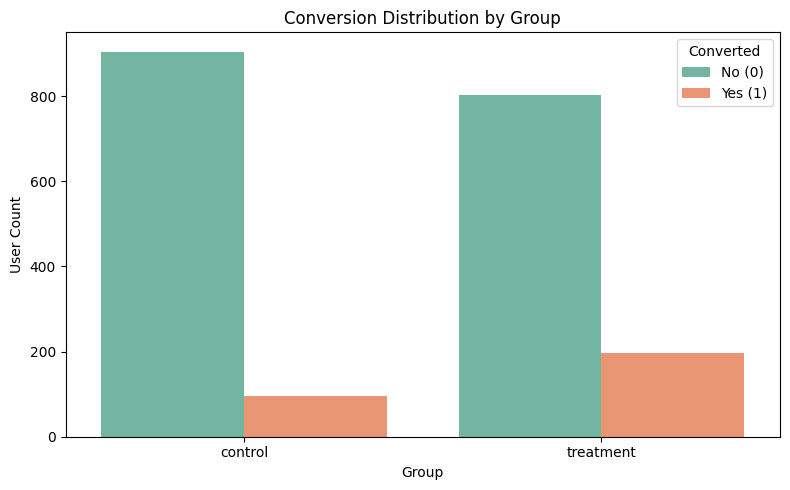


Summary of conversion rates:
            mean  count  sum
group                       
control    0.095   1000   95
treatment  0.196   1000  196


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conversion_distribution(df):
    """
    Plots a bar chart showing count of conversions (0 and 1)
    for each group (control and treatment).

    Parameters:
    - df: DataFrame with 'group' and 'converted' columns
    """
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='group', hue='converted', palette='Set2')
    plt.title('Conversion Distribution by Group')
    plt.xlabel('Group')
    plt.ylabel('User Count')
    plt.legend(title='Converted', labels=['No (0)', 'Yes (1)'])
    plt.tight_layout()
    plt.show()

# Example usage:
plot_conversion_distribution(data)
# Optional: summary
summary = data.groupby('group')['converted'].agg(['mean', 'count', 'sum'])
print("\nSummary of conversion rates:")
print(summary)

In [ ]:
ccr=float(data.loc[data['group']=='control','converted'].mean())
tcr=float(data.loc[data['group']=='treatment','converted'].mean())
print(f"Control Conversion Rate: {ccr}")
print(f"Treatment Conversion Rate: {tcr}")

Control Conversion Rate: 0.095
Treatment Conversion Rate: 0.196


In [ ]:
cstd=float(data.loc[data['group']=='control','converted'].std())
tstd=float(data.loc[data['group']=='treatment','converted'].std())
print(f"Control Standard Deviation: {cstd}")
print(f"Treatment Standard Deviation: {tstd}")

Control Standard Deviation: 0.293361655744339
Treatment Standard Deviation: 0.3971671458488767


## Central Limit Theorem (CLT) Application

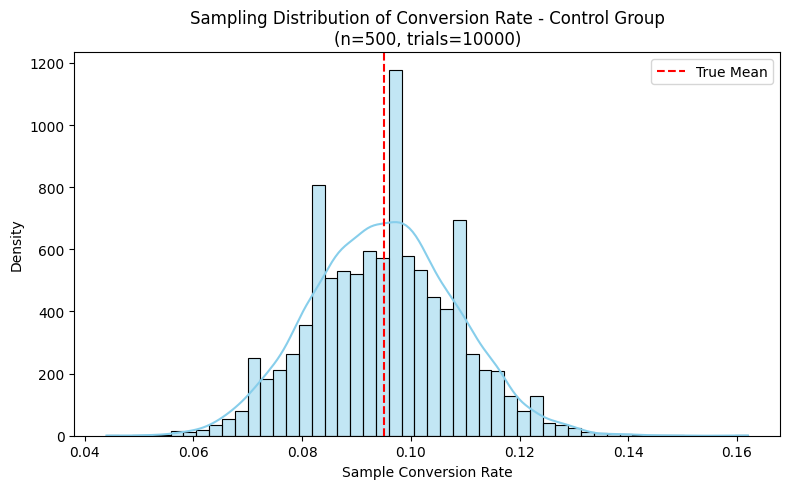

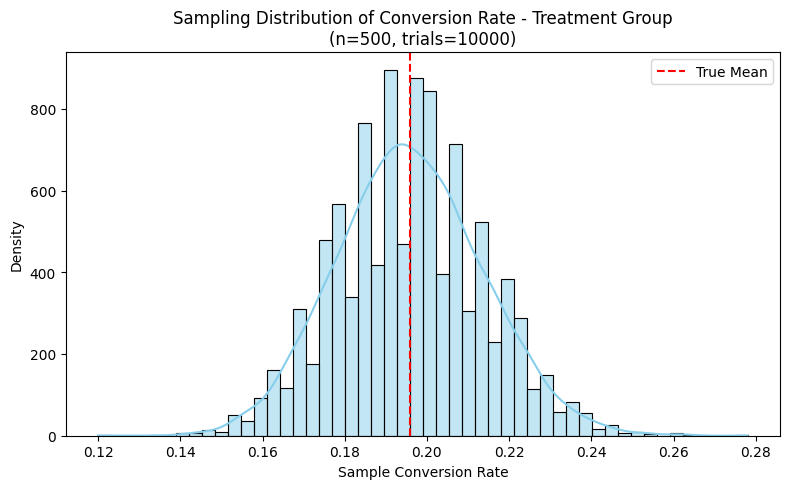

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def simulate_sampling_distribution(df, group_name, n=500, trials=10000, seed=None):
    """
    Simulate the sampling distribution of the conversion rate for a given group.

    Parameters:
    - df: DataFrame with 'group' and 'converted'
    - group_name: 'control' or 'treatment'
    - n: sample size per trial
    - trials: number of resamples to simulate
    - seed: random seed

    Returns:
    - List of sample conversion rates
    """
    if seed is not None:
        np.random.seed(seed)

    group_data = df[df['group'] == group_name]['converted'].values
    sample_means = [
        np.random.choice(group_data, size=n, replace=True).mean()
        for _ in range(trials)
    ]

    # Plot
    plt.figure(figsize=(8, 5))
    sns.histplot(sample_means, kde=True, bins=50, color='skyblue')
    plt.axvline(np.mean(group_data), color='red', linestyle='--', label='True Mean')
    plt.title(f"Sampling Distribution of Conversion Rate - {group_name.capitalize()} Group\n(n={n}, trials={trials})")
    plt.xlabel('Sample Conversion Rate')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()



# Example usage
simulate_sampling_distribution(data, group_name='control', n=500, trials=10000, seed=42)
simulate_sampling_distribution(data, group_name='treatment', n=500, trials=10000, seed=42)


## Confidence Interval


In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_ci_difference(df, confidence):
    """
    Calculate confidence interval for the difference in conversion rates
    between treatment and control groups.

    Parameters:
    - df: DataFrame with 'group' and 'converted' columns
    - confidence: Confidence level (default 0.95)

    Returns:
    - Tuple: (lower_bound, upper_bound)
    """
    # Group summary
    summary = df.groupby('group')['converted'].agg(['mean', 'count'])

    p1 = summary.loc['control', 'mean']
    p2 = summary.loc['treatment', 'mean']
    n1 = summary.loc['control', 'count']
    n2 = summary.loc['treatment', 'count']

    diff = p2 - p1

    # Standard error
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)

    # Z-score for desired confidence level
    z = norm.ppf(1 - (1 - confidence) / 2)

    margin = z * se
    lower = diff - margin
    upper = diff + margin

    return diff, lower, upper

confidence=1-alpha
diff, ci_lower, ci_upper = calculate_ci_difference(data,confidence)
print(f"Difference in conversion rates (treatment - control): {diff:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")


Difference in conversion rates (treatment - control): 0.1010
95% Confidence Interval: (0.0704, 0.1316)


# Hypothesis test

Null Hypothesis : CR_new = CR_old

Alternate Hypothesis : CR_new > CR_old

In [ ]:
from scipy.stats import norm
import numpy as np

def z_test_proportions(df, alternative):
    """
    Performs a Z-test for the difference in proportions (conversion rates)
    between treatment and control groups.

    Parameters:
    - df: DataFrame with 'group' and 'converted' columns
    - alternative: 'two-sided', 'larger' (treatment > control), or 'smaller'

    Returns:
    - z_score: test statistic
    - p_value: corresponding p-value
    """
    summary = df.groupby('group')['converted'].agg(['sum', 'count'])
    x1, n1 = summary.loc['control']
    x2, n2 = summary.loc['treatment']

    # Pooled proportion
    p_pooled = (x1 + x2) / (n1 + n2)

    # Standard error
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))

    # Z statistic
    p1 = x1 / n1
    p2 = x2 / n2
    z = (p2 - p1) / se_pooled

    # P-value
    if alternative == 'two-sided':
        p_value = 2 * (1 - norm.cdf(abs(z)))
    elif alternative == 'larger':
        p_value = 1 - norm.cdf(z)
    elif alternative == 'smaller':
        p_value = norm.cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'larger', or 'smaller'")

    return z, p_value

# Example usage:
z_stat, p_val = z_test_proportions(data, alternative='larger')
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.7f}")
if(p_val<alpha):
    print("Reject null hypothesis")
    print("The new layout led to a statistically significant increase in 'Add to Cart' conversion rate")
else:
    print("Fail to reject null hypothesis")
    print("The new layout did not led to a statistically significant increase in 'Add to Cart' conversion rate")

Z-statistic: 6.4050
P-value: 0.0000000
Reject null hypothesis
The new layout led to a statistically significant increase in 'Add to Cart' conversion rate


## Effect Size

In [ ]:
# odds ratio
control_success = data[data['group'] == 'control']['converted'].sum()
control_failure = data[data['group'] == 'control']['converted'].shape[0]-control_success
control_odds = control_success / control_failure

treatment_success = data[data['group'] == 'treatment']['converted'].sum()
treatment_failure = data[data['group'] == 'treatment']['converted'].shape[0]-treatment_success
treatment_odds = treatment_success / treatment_failure

odds_ratio = round(treatment_odds / control_odds,2)
print(f"Odds Ratio: {odds_ratio}")

Odds Ratio: 2.32


In [ ]:
# cohen's d

def cohens_d_binary(p1, p2):
    # Pooled std deviation for binary (Bernoulli) outcomes
    pooled_sd = ((p1 * (1 - p1) + p2 * (1 - p2)) / 2) ** 0.5
    d = (p2 - p1) / pooled_sd
    return d



d = cohens_d_binary(ccr, tcr)
print(f"Cohen's d: {d:.4f}")

if abs(d) < 0.2:
    interpretation = "Very small effect (negligible practical difference)."
elif abs(d) < 0.5:
    interpretation = "Small to medium effect (noticeable, but modest)."
elif abs(d) < 0.8:
    interpretation = "Medium to large effect (practically meaningful difference)."
else:
    interpretation = "Large effect (strong practical significance)."

print(f"Interpretation: {interpretation}")

Cohen's d: 0.2894
Interpretation: Small to medium effect (noticeable, but modest).


# Cart Size

In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Parameters
n_users = 5000
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-05-01')
date_range = pd.date_range(start=start_date, end=end_date, periods=n_users)

# Simulate cart sizes (Poisson distribution mimics real cart behavior)
# Most people add 1-3 items, few add more
cart_sizes = np.random.poisson(lam=2.1, size=n_users)
cart_sizes = np.clip(cart_sizes, 0, 10)  # Cap at 10 for realism

# Simulate whether the cart led to purchase (optional)

# Create DataFrame
df_cart = pd.DataFrame({
    'user_id': np.arange(1, n_users + 1),
    'session_date': date_range,
    'cart_size': cart_sizes

})

# Preview
print(df_cart.head())


   user_id                  session_date  cart_size
0        1 2024-01-01 00:00:00.000000000          4
1        2 2024-01-01 00:34:51.298259651          1
2        3 2024-01-01 01:09:42.596519303          3
3        4 2024-01-01 01:44:33.894778955          3
4        5 2024-01-01 02:19:25.193038607          1


## Historical Control Data

In [ ]:
# historic conversion rate
avg_cart_size = float(df_cart['cart_size'].mean())
avg_cart_size

2.0856

## Power Analysis

In [ ]:
alpha = 0.05 #significance level
beta = 0.2
power = 1-beta #statistical power




In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.power import TTestIndPower

# Optional: generate or load historical cart size data
# Simulated data (if you don't have real data)
np.random.seed(42)
cart_sizes = df_cart['cart_size']

# Estimate standard deviation from data
std_dev = np.std(cart_sizes, ddof=1)
print(f"Estimated standard deviation: {std_dev:.2f}")

# Define desired detectable difference in cart size (e.g., 0.3 items)
mean_diff = 0.4

# Calculate Cohen's d
effect_size = mean_diff / std_dev
print(f"Cohen's d (effect size): {effect_size:.3f}")

# Sample size calculation
analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='larger')
print(f"\n📌 Required minimum sample size per group: {int(np.ceil(sample_size))}")


Estimated standard deviation: 1.42
Cohen's d (effect size): 0.282

📌 Required minimum sample size per group: 156


## Generating control and treatment data

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # For reproducibility

# Parameters
n_per_group = 1000
control_mean = 2
treatment_mean = 2.4  # Slight increase in treatment
max_cart_size = 10  # Optional cap

# Generate integer cart sizes using Poisson distribution
control_data = np.random.poisson(lam=control_mean, size=n_per_group)
treatment_data = np.random.poisson(lam=treatment_mean, size=n_per_group)

# Optional: clip very large values to make data more realistic
control_data = np.clip(control_data, 0, max_cart_size)
treatment_data = np.clip(treatment_data, 0, max_cart_size)

# Create DataFrame
df = pd.DataFrame({
    'group': ['control'] * n_per_group + ['treatment'] * n_per_group,
    'cart_size': np.concatenate([control_data, treatment_data])
})

print(df.head())


     group  cart_size
0  control          4
1  control          1
2  control          3
3  control          3
4  control          1


<ipython-input-46-8c7b32efe8b3>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_means, x='group', y='cart_size', palette='Set2')


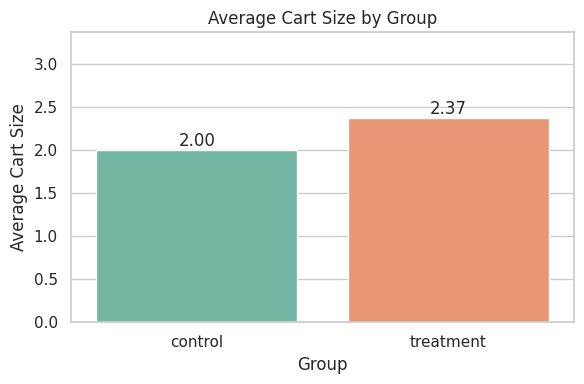

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Calculate group averages
group_means = df.groupby('group')['cart_size'].mean().reset_index()

# Bar plot
plt.figure(figsize=(6, 4))
sns.barplot(data=group_means, x='group', y='cart_size', palette='Set2')

# Add value labels on top
for index, row in group_means.iterrows():
    plt.text(index, row.cart_size + 0.05, f"{row.cart_size:.2f}", ha='center')

plt.title("Average Cart Size by Group")
plt.ylabel("Average Cart Size")
plt.xlabel("Group")
plt.ylim(0, group_means['cart_size'].max() + 1)
plt.tight_layout()
plt.show()


## Central Limit Theorem (CLT) Application

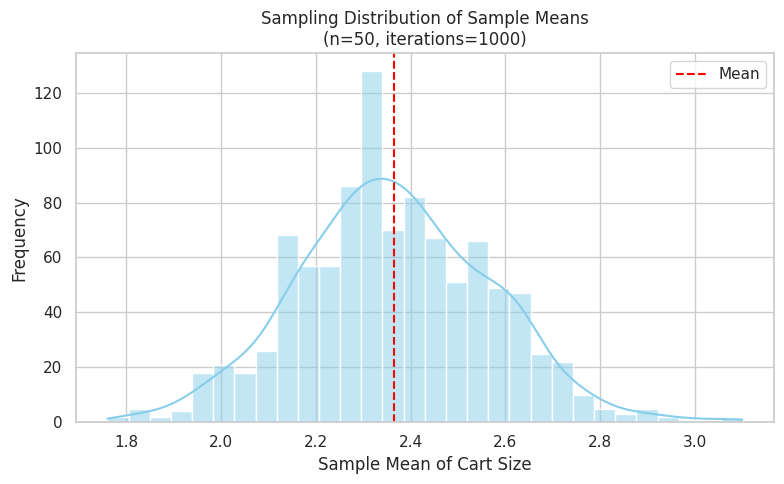

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Use treatment group as an example
data = df[df['group'] == 'treatment']['cart_size']

# Parameters
sample_size = 50
n_iterations = 1000
sample_means = []

# Generate sampling distribution
for _ in range(n_iterations):
    sample = np.random.choice(data, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Plot
plt.figure(figsize=(8, 5))
sns.histplot(sample_means, bins=30, kde=True, color='skyblue')
plt.title(f"Sampling Distribution of Sample Means\n(n={sample_size}, iterations={n_iterations})")
plt.xlabel("Sample Mean of Cart Size")
plt.ylabel("Frequency")
plt.axvline(np.mean(sample_means), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.show()


## Confidence Interval


In [ ]:
import numpy as np
import scipy.stats as stats

# Extract group data
control = df[df['group'] == 'control']['cart_size']
treatment = df[df['group'] == 'treatment']['cart_size']

# Calculate sample statistics
mean_diff = treatment.mean() - control.mean()
se_control = control.std(ddof=1) / np.sqrt(len(control))
se_treatment = treatment.std(ddof=1) / np.sqrt(len(treatment))
se_diff = np.sqrt(se_control**2 + se_treatment**2)

# Degrees of freedom (Welch–Satterthwaite equation)
df_num = (se_control**2 + se_treatment**2)**2
df_denom = ((se_control**2)**2 / (len(control)-1)) + ((se_treatment**2)**2 / (len(treatment)-1))
df_welch = df_num / df_denom

# Confidence interval (95%)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha, df_welch)
margin_of_error = t_crit * se_diff

ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

# Print results
print(f"Difference in means (Treatment - Control): {mean_diff:.3f}")
print(f"95% Confidence Interval: ({ci_lower:.3f}, {ci_upper:.3f})")


Difference in means (Treatment - Control): 0.370
95% Confidence Interval: (0.263, 0.477)


# Hypothesis test

Null Hypothesis : size_new = size_old

Alternate Hypothesis : size_new > size_old

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# Example dummy data (you can replace with your own DataFrame `df`)
# Assuming 'group' is either 'control' or 'treatment' and 'cart_size' is numeric

# Split data
control = df[df['group'] == 'control']['cart_size']
treatment = df[df['group'] == 'treatment']['cart_size']

# Sample sizes
n1, n2 = len(control), len(treatment)

# Means and variances
mean1, mean2 = np.mean(control), np.mean(treatment)
var1, var2 = np.var(control, ddof=1), np.var(treatment, ddof=1)

# Standard error of difference
se_diff = np.sqrt(var1/n1 + var2/n2)

# Welch–Satterthwaite degrees of freedom
numerator = (var1/n1 + var2/n2)**2
denominator = ((var1/n1)**2) / (n1 - 1) + ((var2/n2)**2) / (n2 - 1)
df_welch = numerator / denominator

# t-statistic
t_stat = (mean2 - mean1) / se_diff

# One-tailed p-value (H1: treatment > control)
p_value = 1 - stats.t.cdf(t_stat, df_welch)

# Print results
print("Welch's t-test results:")
print(f"t-statistic = {t_stat:.4f}")
print(f"degrees of freedom ≈ {df_welch:.2f}")
print(f"p-value (one-tailed) = {p_value:.4f}")

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("Result: Reject H₀ → Treatment group has significantly higher cart size.")
else:
    print("Result: Fail to reject H₀ → No significant difference.")


Welch's t-test results:
t-statistic = 5.6990
degrees of freedom ≈ 1993.46
p-value (one-tailed) = 0.0000
Result: Reject H₀ → Treatment group has significantly higher cart size.


## Effect Size

In [ ]:
import numpy as np

# Group data
control = df[df['group'] == 'control']['cart_size']
treatment = df[df['group'] == 'treatment']['cart_size']

# Means and standard deviations
mean_control = np.mean(control)
mean_treatment = np.mean(treatment)
std_control = np.std(control, ddof=1)
std_treatment = np.std(treatment, ddof=1)

# Sample sizes
n1, n2 = len(control), len(treatment)

# Option 1: Unpooled standard deviation (Welch style)
unpooled_std = np.sqrt((std_control**2 + std_treatment**2) / 2)

# Calculate Cohen's d
cohen_d = (mean_treatment - mean_control) / unpooled_std

# Interpretation
if abs(cohen_d) < 0.2:
    interpretation = "Very small/negligible effect"
elif abs(cohen_d) < 0.5:
    interpretation = "Small effect"
elif abs(cohen_d) < 0.8:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"

# Output
print(f"Control mean cart size: {mean_control:.2f}")
print(f"Treatment mean cart size: {mean_treatment:.2f}")
print(f"Cohen's d = {cohen_d:.4f}")
print(f"Interpretation: {interpretation}")


Control mean cart size: 2.00
Treatment mean cart size: 2.37
Cohen's d = 0.2549
Interpretation: Small effect
